# SABR Swaption Surface Calibration & Pricing

## Contexte et objectifs

Ce notebook implémente un **pipeline complet de calibration et de pricing de swaptions** fondé sur le modèle SABR (*Stochastic Alpha Beta Rho*) de Hagan, Kumar, Léger & Woodward (2002). Les swaptions sont les options les plus liquides sur les taux d'intérêt ; leur surface de volatilité implicite constitue l'entrée essentielle de tout desk de taux pour le marking, la couverture et la gestion des risques de convexité.

### Rappel : le contrat swaption

Une **swaption payeur** (*payer swaption*) donne à son détenteur le droit, mais non l'obligation, d'entrer dans un swap de taux fixe-flottant en tant que **payeur fixe** à l'expiry $T$. Son payoff à $T$ est :

$$V_{\text{payer}}(T) = N \cdot A(T,\tau) \cdot \max\!\bigl(S_T - K,\ 0\bigr)$$

où $S_T$ est le taux swap au comptant à $T$, $K$ le strike, $N$ le notionnel, et $A(T,\tau) = \sum_{i} \delta_i P(T, T_i)$ l'annuité (facteur PV01) du swap sous-jacent de tenor $\tau$. La **swaption receveuse** inverse le signe du payoff.

### Structure du pipeline

| Étape | Objet | Module |
|-------|-------|--------|
| 1 | Bootstrap de la courbe des taux zéro-coupon | `yield_curve.py` |
| 2 | Reconstruction de la surface de vol absolue | `data_loader.py` |
| 3 | Calibration SABR slice par slice (expiry × tenor) | `sabr.py` |
| 4 | Pricing Black-76 + Greeks analytiques | `pricer.py` |
| 5 | Analyses : heatmaps, smiles, sensibilité à $\beta$ | `plot_utils.py` |


In [1]:
# ── Paramètres ────────────────────────────────────────────────────────────────
DF_PATH  = "data/market_discount_factors.xlsx"   # chemin discount factors
SW_PATH  = "data/swaption_quotes.xlsx"           # chemin swaptions
BETA     = 0.5    # exposant CEV fixé (0 = normal, 0.5 = CIR-like, 1 = lognormal)
RESTARTS = 5      # restarts aléatoires par slice pour éviter les minima locaux


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=RuntimeWarning)

from data_loader import load_discount_factors, load_full_vol_surface
from yield_curve  import YieldCurve
from sabr         import calibrate_surface, sabr_vol_vec, _parse_tenor
from pricer       import black_price, swaption_price, black_greeks
from plot_utils   import (
    sort_index_numeric,
    plot_sabr_params_tables,
    plot_sabr_heatmaps,
    plot_all_smiles,
    plot_rmse,
    plot_individual_smile,
    plot_price_vega_smile,
    plot_beta_comparison,
)


## 1. Construction de la courbe des taux

### Interpolation log-linéaire des facteurs d'actualisation

À partir des prix de marché $P(0, T_i)$ observés sur un ensemble discret de maturités piliers $\{T_1, \ldots, T_n\}$, on reconstruit une courbe continue par **interpolation log-linéaire** :

$$\ln P(0, T) = \ln P(0, T_i) + \frac{T - T_i}{T_{i+1} - T_i}\bigl[\ln P(0, T_{i+1}) - \ln P(0, T_i)\bigr], \quad T \in [T_i, T_{i+1}]$$

Cela équivaut à supposer un **taux zéro-coupon continu constant par morceaux** entre deux piliers consécutifs, ce qui garantit la positivité des facteurs d'actualisation et la continuité de la courbe. La convention de calcul des maturités est **Act/365**.

### Taux swap forward et annuité

Le **taux swap forward** (ou par) $S(T, \tau)$, sous-jacent de la swaption d'expiry $T$ et de tenor $\tau$, est déterminé par la condition de valeur nulle du swap :

$$S(T, \tau) = \frac{P(0, T) - P(0, T + \tau)}{A(T, \tau)}$$

avec l'**annuité** (PV01 du swap sous-jacent, évaluée en $t=0$) :

$$A(T, \tau) = \sum_{i=1}^{n} \delta_i \cdot P(0, T_i), \quad \delta_i = \frac{1}{\text{freq}}, \quad T_i \in \left]T,\, T+\tau\right]$$

$S(T,\tau)$ est la valeur du taux fixe qui rend le swap de valeur nulle aujourd'hui ; c'est le **forward** naturel du sous-jacent de la swaption dans la mesure annuité $\mathbb{Q}^A$.


In [3]:
df_raw = load_discount_factors(DF_PATH)
yc     = YieldCurve(df_raw)

print(f"Date de référence : {yc.ref_date.date()}")
print(f"Nombre de piliers  : {len(df_raw)}")
print(f"Maturité min/max   : {yc._T[0]:.2f}y – {yc._T[-1]:.2f}y")


Date de référence : 2005-09-29
Nombre de piliers  : 43
Maturité min/max   : 0.00y – 50.04y


In [4]:
print("Piliers de la courbe :")
print(yc.pillar_summary().to_string(index=False))


Piliers de la courbe :
  T_years   P(0,T)  zero_rate
 0.000000 0.999942        inf
 0.010959 0.999710   0.026466
 0.021918 0.999470   0.024188
 0.087671 0.998059   0.022161
 0.169863 0.996281   0.021935
 0.473973 0.989593   0.022072
 0.709589 0.984243   0.022383
 0.978082 0.977920   0.022828
 1.224658 0.971923   0.023254
 1.471233 0.965760   0.023681
 1.726027 0.959287   0.024081
 1.975342 0.952856   0.024447
 2.221918 0.946414   0.024787
 3.005479 0.925790   0.025656
 4.005479 0.898422   0.026742
 5.005479 0.870275   0.027759
 6.005479 0.841442   0.028747
 7.002740 0.812133   0.029716
 8.008219 0.782237   0.030668
 9.008219 0.752476   0.031570
10.008219 0.723171   0.032384
11.010959 0.694473   0.033113
12.008219 0.666446   0.033793
13.005479 0.639278   0.034402
14.010959 0.612743   0.034959
15.013699 0.587727   0.035401
16.013699 0.563523   0.035816
17.013699 0.540313   0.036183
18.010959 0.518115   0.036509
19.016438 0.496713   0.036797
20.016438 0.476246   0.037061
21.016438 0.45678

In [5]:
print("Taux swap forward (exemples) :")
for exp, ten in [("1y","5y"), ("5y","5y"), ("10y","10y"), ("10y","30y")]:
    s = yc.swap_rate_from_labels(exp, ten)
    print(f"  S({exp:>4s}, {ten:>4s}) = {s:.4%}")


Taux swap forward (exemples) :
  S(  1y,   5y) = 3.0251%
  S(  5y,   5y) = 3.7578%
  S( 10y,  10y) = 4.2569%
  S( 10y,  30y) = 4.1339%


## 2. Chargement de la surface de volatilité de marché

### Structure des cotations swaption

Les teneurs de marché cotent les swaptions sur une grille d'expiries $\times$ tenors. Pour chaque nœud $(T_{\text{exp}}, \tau)$, on dispose :

1. d'une **volatilité ATM** $\sigma_{\text{ATM}}(T_{\text{exp}}, \tau)$ — vol implicite Black au strike $K = S(T_{\text{exp}},\tau)$,
2. de **spreads de volatilité** $\Delta\sigma(T_{\text{exp}}, \tau, \Delta K)$ pour un ensemble de strikes hors-monnaie $\Delta K \in \{-200, -100, -50, -25, +25, +50, +100, +200\}$ bps.

La **volatilité absolue** à chaque strike est reconstituée par :

$$\sigma_{\text{impl}}(K) = \sigma_{\text{ATM}} + \Delta\sigma\!\left(\frac{K - S}{\text{1bp}}\right)$$

Ce format *spread-vs-ATM* est standard sur les marchés de taux car il permet de coter le smile indépendamment du niveau du taux sous-jacent, facilitant la mise à jour quotidienne sans recalibration complète de l'ATM.

### Dimension de la surface

La surface couvre **99 slices** (expiry × tenor), chacune renseignant jusqu'à 9 points de strike (8 hors-monnaie + ATM), soit **259 quotes** au total.


In [6]:
vol_surface = load_full_vol_surface(SW_PATH)
n_pairs = vol_surface[["expiry","tenor"]].drop_duplicates().shape[0]
print(f"Slices (expiry × tenor) : {n_pairs}")
print(f"Total de quotes         : {len(vol_surface)}")
vol_surface.head(12)


Slices (expiry × tenor) : 99
Total de quotes         : 259


,expiry,tenor,strike_spread_bps,vol_spread,atm_vol,implied_vol
0,10y,10y,-200,0.0639,0.144,0.2079
1,10y,10y,-100,0.0225,0.144,0.1665
2,10y,10y,-50,0.0091,0.144,0.1531
3,10y,10y,-25,0.0040,0.144,0.1480
4,10y,10y,0,0.0000,0.144,0.1440
5,10y,10y,25,-0.0031,0.144,0.1409
6,10y,10y,50,-0.0052,0.144,0.1388
7,10y,10y,100,-0.0071,0.144,0.1369
8,10y,10y,200,-0.0047,0.144,0.1393
9,10y,1y,0,0.0000,0.159,0.1590


## 3. Calibration SABR (Hagan et al., 2002)

### Dynamique SABR sous la mesure annuité $\mathbb{Q}^A$

Le modèle SABR décrit l'évolution conjointe du **taux swap forward** $F_t$ et de sa **volatilité stochastique** $\alpha_t$ par le système d'EDSs :

$$\mathrm{d}F_t = \alpha_t\, F_t^{\beta}\, \mathrm{d}W_t^{(1)}, \qquad F_0 = S(T,\tau)$$

$$\mathrm{d}\alpha_t = \nu\, \alpha_t\, \mathrm{d}W_t^{(2)}, \qquad \alpha_0 = \alpha$$

$$\mathrm{d}\langle W^{(1)}, W^{(2)} \rangle_t = \rho\, \mathrm{d}t$$

Le forward $F_t$ suit un **processus CEV** (*Constant Elasticity of Variance*) d'exposant $\beta$, tandis que $\alpha_t$ est un mouvement brownien géométrique (log-normal). Les deux browniens sont corrélés avec coefficient $\rho$.

### Paramètres et leur interprétation financière

| Paramètre | Rôle | Valeur typique (taux EUR) |
|-----------|------|--------------------------|
| $\alpha > 0$ | Niveau de volatilité initial — fixe principalement le niveau ATM | $0.02$ – $0.10$ |
| $\beta \in [0,1]$ | Exposant CEV — fixé *a priori*, contrôle le *backbone* de la surface | $0$ ou $0.5$ |
| $\rho \in (-1,1)$ | Corrélation spot-vol — génère **l'asymétrie** (*skew*) du smile | $-0.5$ – $0.0$ |
| $\nu > 0$ | Vol-of-vol — contrôle la **convexité** (*wings*) du smile | $0.1$ – $0.8$ |

> **Interprétation du signe de $\rho$ :** En taux, $\rho < 0$ traduit le fait qu'une hausse des taux (hausse de $F$) s'accompagne d'une baisse de la volatilité. Cela engendre un skew négatif (*put* > *call* en vol), cohérent avec l'observation de marché que les swaptions OTM receveuses sont plus chères en vol que les payeuses équidistantes.

### Formule de vol implicite (expansion asymptotique de Hagan)

Le modèle SABR n'admet pas de formule fermée exacte pour la vol implicite Black. Hagan et al. (2002) proposent une **expansion asymptotique en $T$** (petite maturité, hors-monnaie modéré) :

$$\sigma_B(F, K, T) \approx \frac{\alpha}{\left(FK\right)^{(1-\beta)/2} \left[1 + \frac{(1-\beta)^2}{24}\ln^2\!\frac{F}{K} + \frac{(1-\beta)^4}{1920}\ln^4\!\frac{F}{K}\right]} \cdot \frac{z}{\chi(z)} \cdot \left[1 + \left(\frac{(1-\beta)^2 \alpha^2}{24(FK)^{1-\beta}} + \frac{\rho\beta\nu\alpha}{4(FK)^{(1-\beta)/2}} + \frac{2-3\rho^2}{24}\nu^2\right)T\right]$$

avec $z = \dfrac{\nu}{\alpha}(FK)^{(1-\beta)/2}\ln\dfrac{F}{K}$ et $\chi(z) = \ln\dfrac{\sqrt{1 - 2\rho z + z^2} + z - \rho}{1-\rho}$.

Au voisinage de $F \approx K$ (ATM), l'expression se simplifie :

$$\sigma_B^{\text{ATM}}(F,T) \approx \frac{\alpha}{F^{1-\beta}}\left[1 + \left(\frac{(1-\beta)^2\alpha^2}{24 F^{2-2\beta}} + \frac{\rho\beta\nu\alpha}{4 F^{1-\beta}} + \frac{2-3\rho^2}{24}\nu^2\right)T\right]$$

### Procédure de calibration

Pour chaque slice $(T_{\text{exp}}, \tau)$, on fixe $\beta$ et on minimise l'**erreur quadratique pondérée** :

$$(\hat{\alpha}, \hat{\rho}, \hat{\nu}) = \arg\min_{\alpha,\rho,\nu} \sum_{i} w_i \left[\sigma_B(F, K_i, T; \alpha, \beta, \rho, \nu) - \sigma_i^{\text{mkt}}\right]^2$$

Les poids $w_i$ sur-pondèrent le strike ATM (poids $3\times$) car il constitue la référence liquide principale. L'optimisation est conduite par **L-BFGS-B** (gradient projeté, contraintes de bornes) avec $n=5$ redémarrages aléatoires pour limiter le risque de minima locaux. L'initialisation principale exploite la relation ATM : $\alpha_0 = \sigma_{\text{ATM}} \cdot F^{1-\beta}$.


In [ ]:
print(f"Calibration SABR  (beta={BETA}, restarts={RESTARTS})\n")
surface = calibrate_surface(vol_surface, yc, beta=BETA, n_restarts=RESTARTS)


## 4. Résultats — paramètres SABR calibrés

### Lecture des tableaux

Pour chaque slice $(T_{\text{exp}}, \tau)$, la calibration fournit le triplet $(\hat{\alpha}, \hat{\rho}, \hat{\nu})$ à $\beta = 0.5$ fixé. Quelques lectures financières attendues :

- **$\hat{\alpha}$** : décroît typiquement avec l'expiry (mean-reversion de la vol instantanée) et avec le tenor (liquidité croissante des swaps longs → vol plus stable).
- **$\hat{\rho}$** : négatif sur toute la surface, confirmant le skew de taux. L'amplitude $|\hat{\rho}|$ augmente souvent avec le tenor (swap très long → sensibilité accrue à la concavité de la courbe).
- **$\hat{\nu}$** : mesure la *wingedness* du smile ; des valeurs élevées indiquent un marché prêt à payer une prime significative pour les options très hors-monnaie.
- **RMSE (%)** : écart quadratique moyen entre la vol modèle et la vol de marché, exprimé en points de vol absolue. Un RMSE < 5 bps de vol est jugé satisfaisant en pratique.


In [8]:
summary = surface.summary()
summary


,expiry,tenor,F,alpha,beta,rho,nu,rmse_%
0,5y,2y,0.035200,0.033363,0.5,0.026951,0.342589,0.016902
1,5y,5y,0.037578,0.031838,0.5,-0.093496,0.345215,0.012306
2,5y,10y,0.039689,0.030460,0.5,-0.106024,0.343447,0.014675
3,5y,20y,0.040792,0.028610,0.5,-0.125104,0.340625,0.016733
4,5y,30y,0.040524,0.027611,0.5,-0.139149,0.334525,0.014186
5,10y,2y,0.041672,0.028737,0.5,0.012833,0.303067,0.013666
6,10y,5y,0.042269,0.028148,0.5,-0.132093,0.295395,0.013515
7,10y,10y,0.042569,0.027859,0.5,-0.145821,0.298045,0.011061
8,10y,20y,0.041917,0.026160,0.5,-0.167895,0.296542,0.012570
9,10y,30y,0.041339,0.025036,0.5,-0.173220,0.296172,0.010847


In [ ]:
plot_sabr_params_tables(summary)



── α (alpha) ──
tenor         2y        5y       10y       20y       30y
expiry                                                  
5y      0.033363  0.031838  0.030460  0.028610  0.027611
10y     0.028737  0.028148  0.027859  0.026160  0.025036
20y     0.024606  0.024618  0.024377  0.022429  0.021933
30y     0.023453  0.023239  0.023443  0.022199  0.020249

── ρ (rho) ──
tenor         2y        5y       10y       20y       30y
expiry                                                  
5y      0.026951 -0.093496 -0.106024 -0.125104 -0.139149
10y     0.012833 -0.132093 -0.145821 -0.167895 -0.173220
20y    -0.103358 -0.151280 -0.159289 -0.199695 -0.197966
30y    -0.093733 -0.138015 -0.157897 -0.150739  0.035022

── ν (nu) ──
tenor         2y        5y       10y       20y       30y
expiry                                                  
5y      0.342589  0.345215  0.343447  0.340625  0.334525
10y     0.303067  0.295395  0.298045  0.296542  0.296172
20y     0.248308  0.245127  0.244309  0.24

## 5. Heatmaps des paramètres SABR

Représentation matricielle des trois paramètres calibrés $(\alpha, \rho, \nu)$ sur la grille expiry × tenor. Cette visualisation permet d'identifier d'éventuelles discontinuités ou anomalies dans la surface calibrée, qui signaleraient soit des données de marché aberrantes, soit une instabilité numérique de la calibration sur certaines slices.


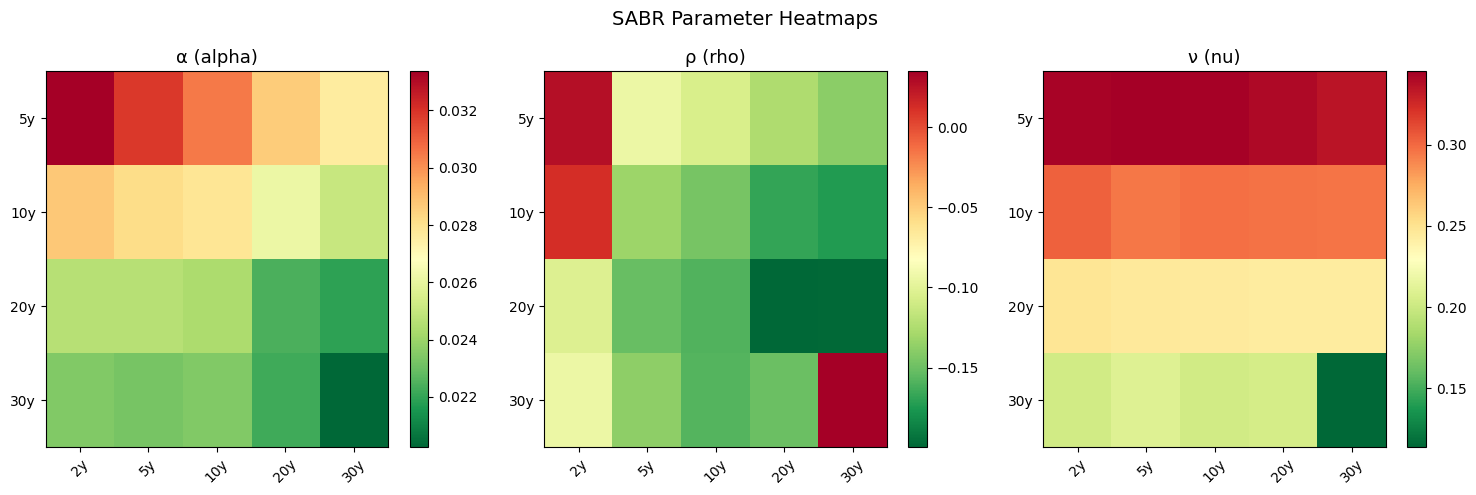

In [ ]:
plot_sabr_heatmaps(summary)


## 6. Smiles de volatilité — marché vs modèle SABR

Superposition, pour chaque slice, de la **courbe de vol implicite SABR** (continue) et des **quotes de marché** (points discrets). La qualité visuelle de l'ajustement complète l'information fournie par le RMSE : on vérifie en particulier que les ailes du smile (strikes très hors-monnaie) sont bien reproduites sans sur-ajustement artificiel au centre.


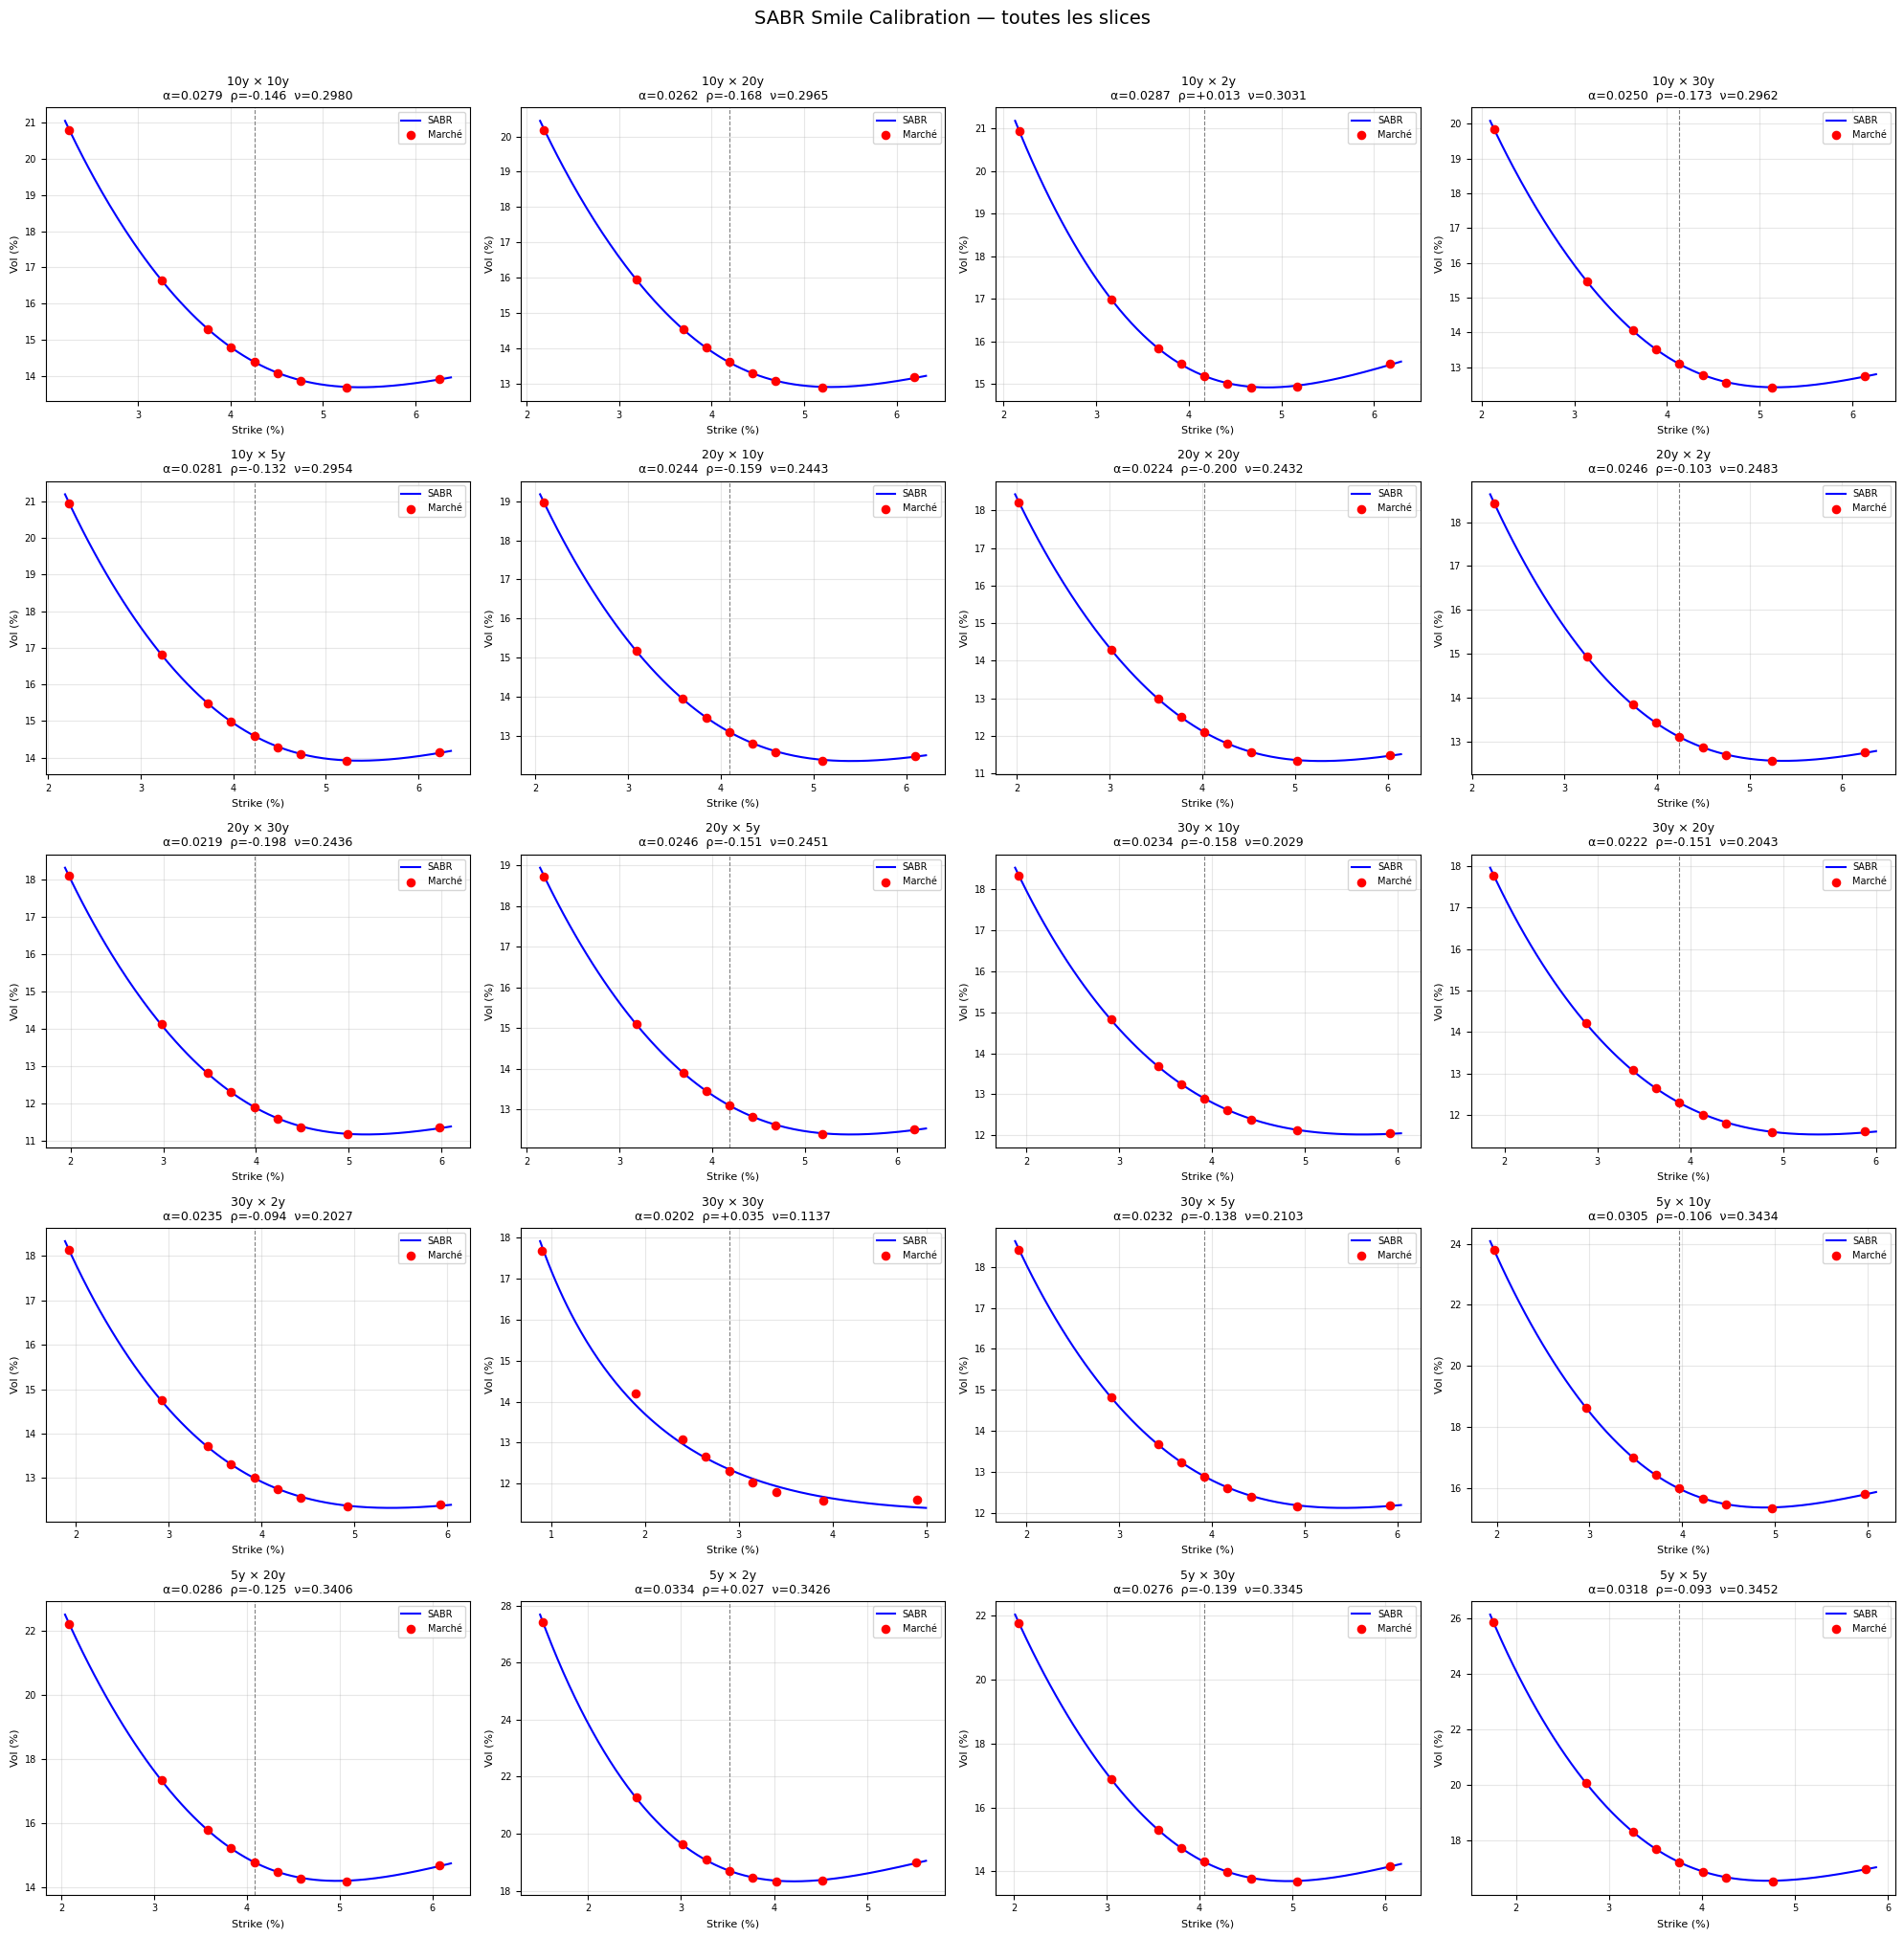

In [ ]:
plot_all_smiles(surface, vol_surface)


## 7. Qualité de la calibration — RMSE par slice

Classement des slices par RMSE croissant. Les slices les moins bien ajustées méritent une attention particulière : elles peuvent indiquer un manque de liquidité (données de marché peu fiables), une inadéquation du modèle sur certaines zones de la surface (expiries très courtes, où l'expansion asymptotique devient moins précise), ou un minimum local dans l'optimisation.


RMSE par slice (du meilleur fit au moins bon) :
   expiry tenor    rmse_%
1     10y   30y  0.010847
2     10y   10y  0.011061
3     20y    5y  0.011338
4     20y   10y  0.012184
5      5y    5y  0.012306
6     10y   20y  0.012570
7     20y    2y  0.013359
8     30y   10y  0.013408
9     10y    5y  0.013515
10    10y    2y  0.013666
11     5y   30y  0.014186
12     5y   10y  0.014675
13    20y   20y  0.016004
14    30y    5y  0.016183
15    20y   30y  0.016187
16     5y   20y  0.016733
17     5y    2y  0.016902
18    30y    2y  0.017165
19    30y   20y  0.020680
20    30y   30y  0.142120

Moyenne : 0.0208%
Max     : 0.1421%  (30y x 30y)
Min     : 0.0108%  (10y x 30y)


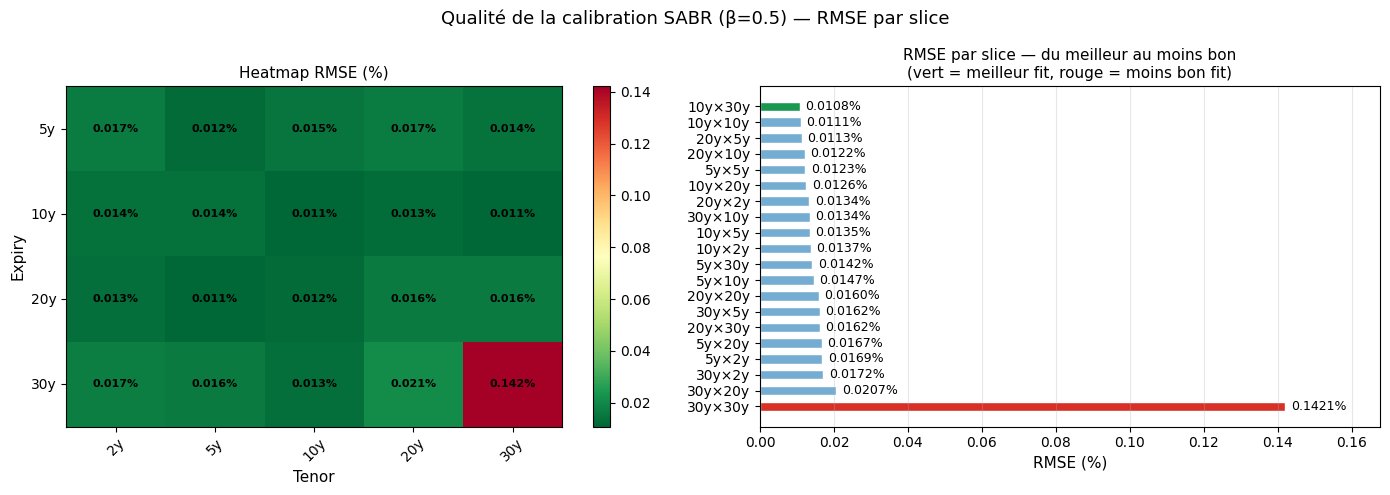

In [ ]:
plot_rmse(summary, BETA)


## 8. Smile individuel — analyse d'une slice

Zoom sur une slice choisie par l'utilisateur, avec affichage des paramètres calibrés et du RMSE associé. Modifier les variables `EXPIRY` et `TENOR` pour explorer différentes zones de la surface.


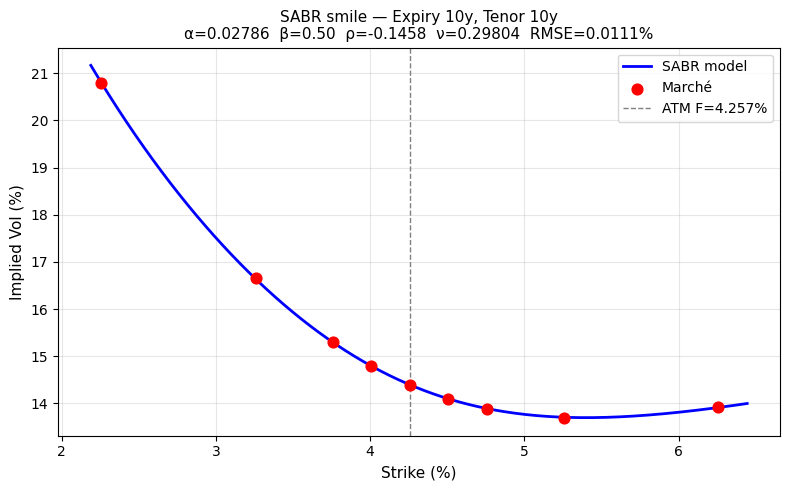


Forward rate F = 4.2569%
Paramètres SABR : alpha=0.027859, beta=0.5, rho=-0.145821, nu=0.298045
RMSE            : 0.0111%


In [ ]:
# ── Choisir une slice ────────────────────────────────────────────────────
EXPIRY = "10y"   # options : 5y, 10y, 20y, 30y
TENOR  = "10y"   # options : 2y, 5y, 10y, 20y, 30y
# ─────────────────────────────────────────────────────────────────────────

plot_individual_smile(surface, vol_surface, EXPIRY, TENOR)


---
## 9. Pricing d'un swaption — modèle Black-76 avec vol SABR

### Le modèle Black (1976) pour les swaptions

Sous la **mesure annuité** $\mathbb{Q}^A$ (numéraire $= N \cdot A(T, \tau)$), le taux swap forward $F_t$ est une martingale. Black (1976) suppose que $F_T$ est log-normale :

$$F_T \sim \mathcal{LN}\!\left(F_0,\; \sigma^2 T\right)$$

Le **prix non-actualisé** (en fraction d'annuité-notionnel) d'une **swaption payeuse** est alors :

$$V_{\text{payer}} = N \cdot A(T,\tau) \cdot \bigl[F \,\Phi(d_1) - K\, \Phi(d_2)\bigr]$$

et d'une **swaption receveuse** :

$$V_{\text{receveur}} = N \cdot A(T,\tau) \cdot \bigl[K\, \Phi(-d_2) - F\, \Phi(-d_1)\bigr]$$

avec :

$$d_1 = \frac{\ln(F/K) + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

La volatilité $\sigma$ est **extraite de la surface SABR calibrée** au strike $K$ exact, ce qui permet de capturer l'effet smile sur le prix.

### Pipeline de pricing

$$F = S(T_{\text{exp}},\, \tau) \quad\longleftarrow\quad \text{courbe des taux}$$

$$A = A(T_{\text{exp}},\, \tau) \quad\longleftarrow\quad \text{courbe des taux}$$

$$\sigma = \sigma_{\text{SABR}}(F, K, T;\, \hat{\alpha}, \beta, \hat{\rho}, \hat{\nu}) \quad\longleftarrow\quad \text{surface calibrée}$$

$$\text{Prix} = N \cdot A \cdot V_{\text{Black}}(F, K, \sigma, T)$$

### Greeks analytiques

Les sensibilités sont calculées en fermé dans le cadre Black. Notations : $\varphi = \phi(d_1)$ densité normale standard évaluée en $d_1$, $\omega = +1$ (payeur) ou $-1$ (receveur).

| Greek | Formule | Unité reportée |
|-------|---------|---------------|
| **Delta** $\partial V / \partial F$ | $\omega \cdot N \cdot A \cdot \Phi(\omega d_1)$ | €/bp de $F$ |
| **Vega** $\partial V / \partial \sigma$ | $N \cdot A \cdot F\,\varphi\,\sqrt{T}$ | € pour $\Delta\sigma = +1\%$ |
| **Gamma** $\partial^2 V / \partial F^2$ | $N \cdot A \cdot \varphi\,/\,(F\sigma\sqrt{T})$ | € / bp² |
| **Vanna** $\partial^2 V / \partial F\,\partial\sigma$ | $-N \cdot A \cdot \varphi\,d_2\,/\,\sigma$ | € / (bp × 1% vol) |
| **Volga** $\partial^2 V / \partial\sigma^2$ | $N \cdot A \cdot F\,\varphi\,\sqrt{T}\cdot d_1 d_2\,/\,\sigma$ | € / (1% vol)² |

> **Vanna et Volga** sont les deux Greeks de second ordre les plus pertinents pour le risk management d'un portefeuille de swaptions soumis à des mouvements simultanés de taux et de vol. Ils apparaissent naturellement dans les approches de couverture vega-neutre type *Vanna-Volga pricing*.


In [14]:
# ── Paramètres du swaption à pricer ──────────────────────────────────────────
PR_EXPIRY     = "10y"       # expiry de l'option  (doit être dans la surface calibrée)
PR_TENOR      = "10y"       # tenor du swap sous-jacent
PR_STRIKE_BPS = 0           # strike en bps relatif à l'ATM (0 = ATM, +50 = ATM+50bps, etc.)
PR_NOTIONAL   = 1_000_000   # notionnel en euros
PR_TYPE       = "payer"     # "payer" ou "receveur"
# ─────────────────────────────────────────────────────────────────────────────


In [ ]:
# Fonctions importées depuis pricer.py : black_price, swaption_price, black_greeks
print('Fonctions de pricing chargées.')


Fonctions de pricing chargées.


In [16]:
# ── Calcul ───────────────────────────────────────────────────────────────────
T_pr  = _parse_tenor(PR_EXPIRY)
ten_pr = _parse_tenor(PR_TENOR)

F_pr  = yc.swap_rate(T_pr, ten_pr)
A_pr  = yc.annuity(T_pr, ten_pr)
K_pr  = F_pr + PR_STRIKE_BPS / 10_000.0

p_pr  = surface.get(PR_EXPIRY, PR_TENOR)
if p_pr is None:
    raise ValueError(f"Pas de calibration SABR pour ({PR_EXPIRY}, {PR_TENOR}). "
                     f"Slices disponibles : {list(surface.results.keys())}")

sigma_pr = sabr_vol_vec(F_pr, np.array([K_pr]), T_pr,
                         p_pr.alpha, p_pr.beta, p_pr.rho, p_pr.nu)[0]

price_pr = swaption_price(F_pr, K_pr, sigma_pr, T_pr, A_pr, PR_NOTIONAL, PR_TYPE)

# ── Affichage ────────────────────────────────────────────────────────────────
print("=" * 55)
print(f"  Swaption {PR_TYPE.upper()}  —  {PR_EXPIRY} x {PR_TENOR}")
print("=" * 55)
print(f"  Notionnel          : {PR_NOTIONAL:>15,.0f} €")
print(f"  Forward swap rate  : {F_pr:>15.4%}")
print(f"  Strike             : {K_pr:>15.4%}  ({PR_STRIKE_BPS:+d} bps vs ATM)")
print(f"  Annuité A(T,tenor) : {A_pr:>15.6f}")
print(f"  SABR vol (σ)       : {sigma_pr:>15.4%}")
print(f"  Expiry (années)    : {T_pr:>15.2f}")
print("-" * 55)
print(f"  PRIX               : {price_pr:>15,.2f} €")
print(f"  Prix / Notionnel   : {price_pr/PR_NOTIONAL:>15.4%}")
print("=" * 55)


  Swaption PAYER  —  10y x 10y
  Notionnel          :       1,000,000 €
  Forward swap rate  :         4.2569%
  Strike             :         4.2569%  (+0 bps vs ATM)
  Annuité A(T,tenor) :        5.798422
  SABR vol (σ)       :        14.3970%
  Expiry (années)    :           10.00
-------------------------------------------------------
  PRIX               :       44,447.15 €
  Prix / Notionnel   :         4.4447%


In [17]:
greeks = black_greeks(F_pr, K_pr, sigma_pr, T_pr, A_pr, PR_NOTIONAL, PR_TYPE)

print("Greeks (formule de Black analytique)")
print("-" * 55)
print(f"  Delta   (€/bp de F)        : {greeks['delta_bp']:>12,.2f} €")
print(f"  Vega    (€ pour +1% de vol) : {greeks['vega_1pct']:>12,.2f} €")
print(f"  Gamma   (€/bp² de F)        : {greeks['gamma_bp2']:>12,.4f} €")
print(f"  Vanna   (Δdelta / +1% vol)  : {greeks['vanna']:>12,.4f} €")
print(f"  Volga   (Δvega  / +1% vol)  : {greeks['volga']:>12,.4f} €")
print("-" * 55)
print()
print("Interprétation :")
print(f"  → Si le taux forward monte de 1bp  : P&L ≈ {greeks['delta_bp']:+,.0f} €")
print(f"  → Si la vol monte de 1%            : P&L ≈ {greeks['vega_1pct']:+,.0f} €")


Greeks (formule de Black analytique)
-------------------------------------------------------
  Delta   (€/bp de F)        :       342.13 €
  Vega    (€ pour +1% de vol) :     3,034.30 €
  Gamma   (€/bp² de F)        :       1.1631 €
  Vanna   (Δdelta / +1% vol)  :       3.5640 €
  Volga   (Δvega  / +1% vol)  :     -10.9212 €
-------------------------------------------------------

Interprétation :
  → Si le taux forward monte de 1bp  : P&L ≈ +342 €
  → Si la vol monte de 1%            : P&L ≈ +3,034 €


## 10. Profils prix et vega en fonction du strike

Ces trois graphiques illustrent la dépendance au strike du prix, du vega et de la volatilité implicite SABR pour le swaption sélectionné. On observe notamment que le **vega est maximal au voisinage de l'ATM** (où la probabilité risque-neutre $\Phi(d_1)$ évolue le plus rapidement) et décroît symétriquement vers les ailes.


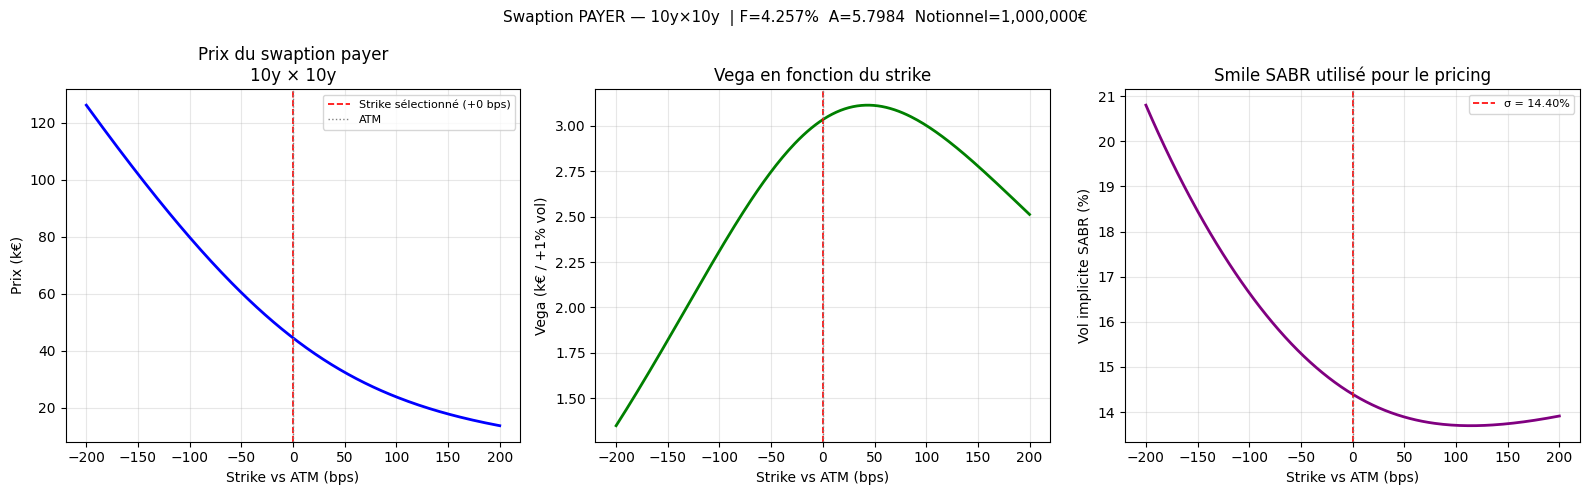

In [ ]:
plot_price_vega_smile(
    surface, vol_surface, yc,
    expiry=PR_EXPIRY, tenor=PR_TENOR,
    strike_bps=PR_STRIKE_BPS,
    notional=PR_NOTIONAL,
    option_type=PR_TYPE,
)


## 11. Vérification de la parité payer–receveur

### Relation de parité (put-call parity des swaptions)

La parité payer–receveur est une identité **modèle-indépendante** qui découle directement de l'absence d'arbitrage. Elle s'écrit :

$$V_{\text{payer}}(K) - V_{\text{receveur}}(K) = N \cdot A(T,\tau) \cdot (F - K)$$

Le membre de droite est la valeur actuelle du **swap forward** : entrer payeur fixe au taux $K$ vaut exactement l'écart actualisé entre le taux par $F$ et le strike $K$, pondéré par l'annuité et le notionnel.

**Preuve succincte :** à l'expiry $T$, le payoff d'un straddle synthétique (long payer, short receveur au même strike) est :

$$\max(S_T - K, 0) - \max(K - S_T, 0) = S_T - K$$

En actualisant sous $\mathbb{Q}^A$ et en exploitant le fait que $F$ est la valeur forward de $S_T$ :

$$V_{\text{payer}} - V_{\text{receveur}} = N \cdot A \cdot \mathbb{E}^{\mathbb{Q}^A}[S_T - K] = N \cdot A \cdot (F - K)$$

Cette relation constitue un **test de cohérence numérique** de l'implémentation : toute erreur dans le signe de l'option, la formule $d_1/d_2$, ou le calcul de l'annuité se traduirait par un écart non nul.


In [19]:
price_payer    = swaption_price(F_pr, K_pr, sigma_pr, T_pr, A_pr, PR_NOTIONAL, "payer")
price_receveur = swaption_price(F_pr, K_pr, sigma_pr, T_pr, A_pr, PR_NOTIONAL, "receveur")
parity_lhs     = price_payer - price_receveur
parity_rhs     = PR_NOTIONAL * A_pr * (F_pr - K_pr)   # valeur du swap forward

print("Put-Call Parity : Payer - Receveur = A × N × (F - K)")
print("-" * 55)
print(f"  Prix payer            : {price_payer:>15,.2f} €")
print(f"  Prix receveur         : {price_receveur:>15,.2f} €")
print(f"  Payer - Receveur      : {parity_lhs:>15,.2f} €")
print(f"  A × N × (F - K)       : {parity_rhs:>15,.2f} €")
print(f"  Erreur (numérique)    : {abs(parity_lhs - parity_rhs):>15.6f} €")
print("-" * 55)
ok = abs(parity_lhs - parity_rhs) < 1e-4
print(f"  Parité vérifiée       : {'✓ OUI' if ok else '✗ NON'}")


Put-Call Parity : Payer - Receveur = A × N × (F - K)
-------------------------------------------------------
  Prix payer            :       44,447.15 €
  Prix receveur         :       44,447.15 €
  Payer - Receveur      :            0.00 €
  A × N × (F - K)       :            0.00 €
  Erreur (numérique)    :        0.000000 €
-------------------------------------------------------
  Parité vérifiée       : ✓ OUI


## 12. Sensibilité au choix de $\beta$ — comparaison des smiles calibrés

### Rôle de $\beta$ : le *backbone* du smile

L'exposant $\beta$ définit la relation entre le **niveau du taux** et la **volatilité ATM** lorsque $F$ se déplace dans le temps (*backbone*). On montre que, pour la vol ATM au premier ordre :

$$\sigma_B^{\text{ATM}} \approx \frac{\alpha}{F^{1-\beta}}$$

Ainsi :
- **$\beta = 0$ (modèle normal)** : $\sigma_B^{\text{ATM}} \propto \alpha$, indépendant de $F$ — le backbone est *plat*, cohérent avec un modèle additif pour les taux (distribution normale tronquée). Ce choix est devenu standard dans les environnements de taux bas/négatifs car il autorise $F \leq 0$.
- **$\beta = 0.5$ (racine carrée, CIR-like)** : $\sigma_B^{\text{ATM}} \propto \alpha / \sqrt{F}$ — intermédiaire, fréquemment utilisé comme compromis.
- **$\beta = 1$ (modèle log-normal)** : $\sigma_B^{\text{ATM}} \propto \alpha / F$ — le backbone reproduit le comportement log-normal du Black original. Inadapté en cas de taux négatifs.

### Invariance partielle et identification

Un résultat important est que **plusieurs combinaisons $(\alpha, \beta)$ peuvent produire des smiles quasi-identiques** sur la grille de strikes observée (*near-degeneracy*). Le choix de $\beta$ est donc souvent guidé par :
1. des considérations **économiques** sur la distribution des taux (normal vs log-normal),
2. la **cohérence avec le modèle de taux sous-jacent** (HJM, LMM),
3. la **stabilité temporelle** des paramètres $\hat{\rho}$ et $\hat{\nu}$ recalibrés au cours du temps.

Les graphiques comparent les smiles et les résidus pour $\beta \in \{0, 0.5, 1\}$ sur la slice sélectionnée.


Calibration sur la slice 10y × 10y  (F = 4.2569%)

Beta          Alpha        Rho         Nu       RMSE
----------------------------------------------------
  0.0      0.005749   0.143397   0.271949    0.0847%
  0.5      0.027859  -0.145821   0.298045    0.0111%
  1.0      0.138964  -0.368857   0.347163    0.0654%


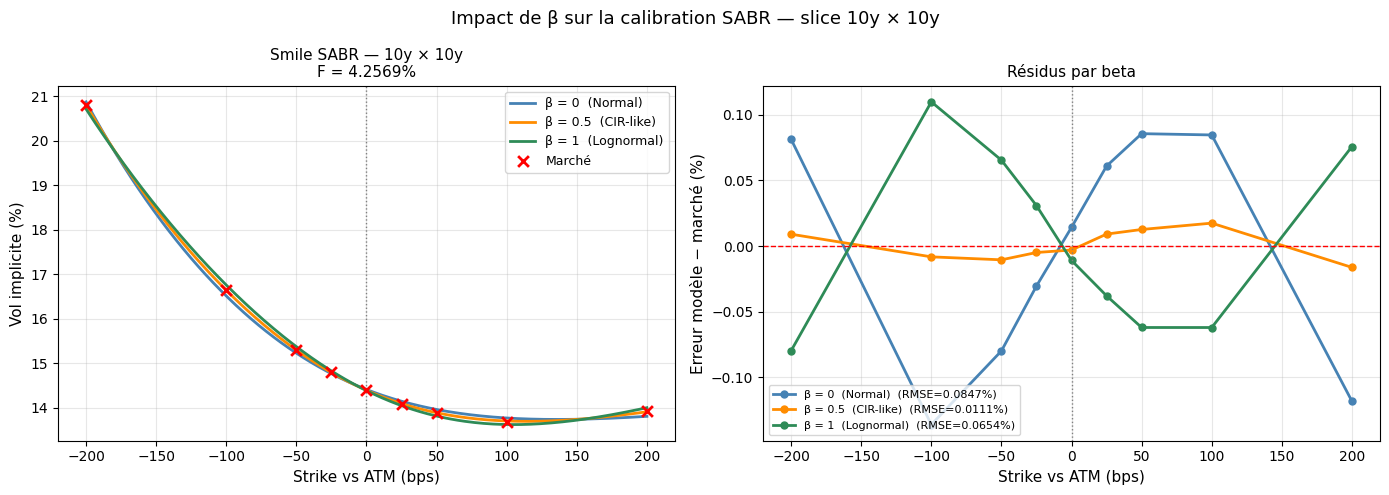

In [ ]:
# ── Slice à analyser ─────────────────────────────────────────────────────
BETA_EXP = "10y"   # expiry  (doit être dans la surface calibrée)
BETA_TEN = "10y"   # tenor
# ─────────────────────────────────────────────────────────────────────────

plot_beta_comparison(vol_surface, yc, BETA_EXP, BETA_TEN)
